# Alzheimer's / Dementia Detection from Speech Transcripts
### Cookie Theft Task — Fixed & Cleaned Pipeline

**Key fixes applied:**
- ✅ Data augmentation moved **inside** the CV loop → no leakage
- ✅ Proper **held-out test set** (20%) touched only once at the very end
- ✅ Single model: **Gradient Boosting** (best for tabular clinical data)
- ✅ Per-fold **std deviation** reported alongside mean
- ✅ Final evaluation on clean test set with classification report + confusion matrix

In [ ]:
!pip install scikit-learn joblib pandas numpy

In [ ]:
from google.colab import files
uploaded = files.upload()

In [1]:
import pandas as pd
import numpy as np
import re
import random
import json
import warnings
from collections import Counter

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, f1_score, accuracy_score
)
import joblib

warnings.filterwarnings('ignore')
random.seed(42)
np.random.seed(42)

print("Libraries loaded.")

Libraries loaded.


## 1. Load Data

In [2]:
df = pd.read_csv('/content/synthetic_augmented_data.csv')

# Create binary label
df['label'] = (df['output'] == 'dementia').astype(int)  # 1=dementia, 0=control

print(f"Dataset loaded: {len(df)} samples")
print(f"  Dementia : {df['label'].sum()}")
print(f"  Control  : {(df['label']==0).sum()}")
print(f"  Balance  : {df['label'].mean():.1%} positive")

Dataset loaded: 1992 samples
  Dementia : 1024
  Control  : 968
  Balance  : 51.4% positive


## 2. Feature Extraction

In [3]:
FILLERS = {'uh', 'um', 'er', 'ah', 'like', 'you know', 'i mean', 'well', 'so', 'right'}

def extract_features(text: str) -> dict:
    """
    Extract linguistic features known to discriminate
    Alzheimer's speech from healthy controls (Cookie Theft task).
    """
    text = str(text)
    words_raw = text.split()
    words = [w.lower().strip('.,!?;:') for w in words_raw if w.strip('.,!?;:')]
    sentences = [s.strip() for s in re.split(r'[.!?]', text) if len(s.strip()) > 3]
    n_words = max(len(words), 1)
    n_sents = max(len(sentences), 1)

    # ── Lexical richness ──────────────────────────────────────────────
    unique_words = set(words)
    ttr = len(unique_words) / n_words
    hapax = sum(1 for w, c in Counter(words).items() if c == 1)
    honore = (100 * np.log(n_words)) / max(1 - hapax / max(len(unique_words), 1), 1e-9)
    brunet = n_words ** (len(unique_words) ** -0.165)

    # ── Fluency / disfluency ──────────────────────────────────────────
    filler_count = sum(1 for w in words if w in FILLERS)
    filler_rate = filler_count / n_words
    repetitions = sum(1 for i in range(1, len(words)) if words[i] == words[i-1])
    repetition_rate = repetitions / n_words
    revision_words = {'no', 'wait', 'i mean', 'actually', 'sorry'}
    revision_count = sum(1 for w in words if w in revision_words)

    # ── Syntactic ─────────────────────────────────────────────────────
    mean_sent_len = n_words / n_sents
    sent_lens = [len(s.split()) for s in sentences]
    sent_len_var = np.var(sent_lens) if len(sent_lens) > 1 else 0

    # ── Semantic / content ────────────────────────────────────────────
    iu_words = {
        'cookie', 'jar', 'boy', 'girl', 'stool', 'fall', 'falling', 'tip',
        'mother', 'woman', 'dishes', 'washing', 'sink', 'overflow', 'water',
        'kitchen', 'window', 'curtain', 'outside', 'garden', 'summer',
        'reach', 'reaching', 'hand', 'take', 'taking', 'steal', 'stealing'
    }
    iu_count = sum(1 for w in words if w in iu_words)
    iu_density = iu_count / n_words

    pronouns = {'he', 'she', 'it', 'they', 'him', 'her', 'them', 'this', 'that', 'there'}
    pronoun_rate = sum(1 for w in words if w in pronouns) / n_words

    action_verbs = {'is', 'are', 'get', 'getting', 'wash', 'washing', 'fall', 'falling',
                    'take', 'taking', 'reach', 'reaching', 'tip', 'tipping', 'run', 'running'}
    verb_rate = sum(1 for w in words if w in action_verbs) / n_words

    # ── Structural ────────────────────────────────────────────────────
    word_lengths = [len(w) for w in words]
    mean_word_len = np.mean(word_lengths)
    conjunctions = {'and', 'but', 'because', 'while', 'although', 'since', 'when', 'if'}
    conj_rate = sum(1 for w in words if w in conjunctions) / n_words
    neg_rate = sum(1 for w in words if w in {"not", "no", "never", "don't", "doesn't", "isn't"}) / n_words

    return {
        'n_words': n_words,
        'n_sentences': n_sents,
        'ttr': ttr,
        'honore': honore,
        'brunet': brunet,
        'filler_rate': filler_rate,
        'repetition_rate': repetition_rate,
        'revision_count': revision_count,
        'mean_sent_len': mean_sent_len,
        'sent_len_var': sent_len_var,
        'iu_count': iu_count,
        'iu_density': iu_density,
        'pronoun_rate': pronoun_rate,
        'verb_rate': verb_rate,
        'mean_word_len': mean_word_len,
        'conj_rate': conj_rate,
        'neg_rate': neg_rate,
        'unique_words': len(unique_words),
    }


# Extract features for all original samples
feat_df = pd.DataFrame([extract_features(t) for t in df['input']])
X_all = feat_df.values
y_all = df['label'].values
FEAT_NAMES = list(feat_df.columns)

print(f"Features extracted: {feat_df.shape[1]} features × {feat_df.shape[0]} samples")

Features extracted: 18 features × 1992 samples


## 3. Exploratory Data Analysis

In [4]:
print("=" * 60)
print("EXPLORATORY DATA ANALYSIS")
print("=" * 60)

feat_df['label'] = y_all

key_features = ['ttr', 'filler_rate', 'repetition_rate', 'iu_density',
                'pronoun_rate', 'mean_sent_len', 'brunet', 'verb_rate']

print(f"\n{'Feature':<22} {'Dementia':>10} {'Control':>10} {'Diff%':>8}")
print("-" * 55)
for feat in key_features:
    d_mean = feat_df[feat_df['label']==1][feat].mean()
    c_mean = feat_df[feat_df['label']==0][feat].mean()
    pct = ((d_mean - c_mean) / max(abs(c_mean), 1e-9)) * 100
    print(f"  {feat:<20} {d_mean:>10.4f} {c_mean:>10.4f} {pct:>+8.1f}%")

feat_df = feat_df.drop(columns=['label'])

EXPLORATORY DATA ANALYSIS

Feature                  Dementia    Control    Diff%
-------------------------------------------------------
  ttr                      0.6373     0.6450     -1.2%
  filler_rate              0.0286     0.0101   +184.1%
  repetition_rate          0.0146     0.0049   +195.0%
  iu_density               0.1145     0.1303    -12.1%
  pronoun_rate             0.0611     0.0459    +33.1%
  mean_sent_len            8.6364     9.0417     -4.5%
  brunet                   9.9268    10.0368     -1.1%
  verb_rate                0.0690     0.0908    -24.1%


## 4. Augmentation Helpers

> **Important:** These functions are called **only inside the CV training loop** and when building the final training set — never on the test set.

In [5]:
SYNONYMS = {
    'kitchen': ['room', 'household area'],
    'mother': ['woman', 'lady', 'mom'],
    'boy': ['child', 'kid', 'young one'],
    'girl': ['child', 'kid', 'young one'],
    'cookie': ['biscuit', 'treat', 'snack'],
    'jar': ['container', 'pot', 'tin'],
    'stool': ['step stool', 'small ladder'],
    'sink': ['basin', 'washbasin'],
    'dishes': ['plates', 'crockery', 'utensils'],
    'washing': ['cleaning', 'rinsing'],
    'falling': ['tipping', 'toppling', 'about to fall'],
    'window': ['opening', 'glass pane'],
    'curtain': ['drape', 'blind'],
    'water': ['liquid'],
    'overflow': ['spill over', 'run over'],
    'reach': ['grab', 'get'],
    'see': ['notice', 'observe', 'look at'],
}

def synonym_replace(text: str, n: int = 2) -> str:
    words = text.split()
    indices = list(range(len(words)))
    random.shuffle(indices)
    replaced = 0
    for i in indices:
        w = words[i].lower().strip('.,!?')
        if w in SYNONYMS and replaced < n:
            words[i] = random.choice(SYNONYMS[w])
            replaced += 1
    return ' '.join(words)

def random_insertion(text: str, n: int = 1) -> str:
    fillers = ['uh', 'um', 'er', 'well', 'you know']
    words = text.split()
    for _ in range(n):
        pos = random.randint(0, len(words))
        words.insert(pos, random.choice(fillers))
    return ' '.join(words)

def random_deletion(text: str, p: float = 0.05) -> str:
    words = text.split()
    if len(words) <= 5:
        return text
    return ' '.join(w for w in words if random.random() > p)

def swap_sentences(text: str) -> str:
    sents = [s.strip() for s in re.split(r'(?<=[.!?])\s+', text) if s.strip()]
    if len(sents) < 2:
        return text
    i = random.randint(0, len(sents) - 2)
    sents[i], sents[i+1] = sents[i+1], sents[i]
    return ' '.join(sents)

def augment_texts(texts, labels, n_aug: int = 2):
    """
    Augment a list of (text, label) pairs. Returns augmented features only
    (not the originals) so caller decides how to combine.
    """
    aug_features, aug_labels = [], []
    for text, label in zip(texts, labels):
        ops_dementia = [
            lambda t: random_insertion(t, n=random.randint(1, 3)),
            lambda t: synonym_replace(t, n=1),
            lambda t: random_deletion(t, p=0.04),
        ]
        ops_control = [
            lambda t: synonym_replace(t, n=random.randint(2, 4)),
            lambda t: random_deletion(t, p=0.03),
            lambda t: swap_sentences(t),
        ]
        ops = ops_dementia if label == 1 else ops_control
        for _ in range(n_aug):
            op = random.choice(ops)
            aug_features.append(extract_features(op(text)))
            aug_labels.append(label)
    return pd.DataFrame(aug_features).values, np.array(aug_labels)

print("Augmentation helpers defined (will only run on training folds).")

Augmentation helpers defined (will only run on training folds).


## 5. Train / Test Split

We set aside **20% as a held-out test set** — it is never touched during model selection or cross-validation.

In [6]:
# Stratified split so class ratio is preserved in both halves
(
    X_train_texts, X_test_texts,
    X_train_feats, X_test_feats,
    y_train,       y_test
) = train_test_split(
    df['input'].values,   # raw texts (needed for augmentation)
    X_all,                # pre-computed features
    y_all,
    test_size=0.20,
    random_state=42,
    stratify=y_all
)

print(f"Training set : {len(y_train)} samples  (dementia={y_train.sum()}, control={(y_train==0).sum()})")
print(f"Test set     : {len(y_test)}  samples  (dementia={y_test.sum()}, control={(y_test==0).sum()})")
print("\n✅ Test set is now locked — will only be used once at final evaluation.")

Training set : 1593 samples  (dementia=819, control=774)
Test set     : 399  samples  (dementia=205, control=194)

✅ Test set is now locked — will only be used once at final evaluation.


## 6. Cross-Validation with Leak-Free Augmentation

Augmentation happens **inside each fold** — only on the training portion of that fold, never on the validation portion.

In [7]:
print("=" * 60)
print("5-FOLD STRATIFIED CROSS-VALIDATION (leak-free augmentation)")
print("=" * 60)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_acc, fold_f1, fold_auc = [], [], []

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train_feats, y_train), 1):
    # ── Split this fold ──────────────────────────────────────────────
    X_fold_train_feats = X_train_feats[train_idx]
    X_fold_train_texts = X_train_texts[train_idx]
    y_fold_train       = y_train[train_idx]

    X_fold_val = X_train_feats[val_idx]
    y_fold_val = y_train[val_idx]

    # ── Augment ONLY the training portion of this fold ───────────────
    X_aug, y_aug = augment_texts(X_fold_train_texts, y_fold_train, n_aug=2)
    X_fold_train_full = np.vstack([X_fold_train_feats, X_aug])
    y_fold_train_full = np.concatenate([y_fold_train, y_aug])

    # ── Build and train model ─────────────────────────────────────────
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', GradientBoostingClassifier(
            n_estimators=150,
            learning_rate=0.08,
            max_depth=4,
            subsample=0.8,
            random_state=42
        ))
    ])
    model.fit(X_fold_train_full, y_fold_train_full)

    # ── Evaluate on the CLEAN validation fold ─────────────────────────
    y_pred     = model.predict(X_fold_val)
    y_prob     = model.predict_proba(X_fold_val)[:, 1]

    fold_acc.append(accuracy_score(y_fold_val, y_pred))
    fold_f1.append(f1_score(y_fold_val, y_pred, zero_division=0))
    fold_auc.append(roc_auc_score(y_fold_val, y_prob))

    print(f"  Fold {fold}: Acc={fold_acc[-1]:.3f}  F1={fold_f1[-1]:.3f}  AUC={fold_auc[-1]:.3f}")

print("\n" + "-" * 60)
print(f"  Mean ± Std")
print(f"  Accuracy : {np.mean(fold_acc):.3f} ± {np.std(fold_acc):.3f}")
print(f"  F1 Score : {np.mean(fold_f1):.3f} ± {np.std(fold_f1):.3f}")
print(f"  ROC-AUC  : {np.mean(fold_auc):.3f} ± {np.std(fold_auc):.3f}")
print("-" * 60)

5-FOLD STRATIFIED CROSS-VALIDATION (leak-free augmentation)
  Fold 1: Acc=0.897  F1=0.896  AUC=0.962
  Fold 2: Acc=0.931  F1=0.933  AUC=0.977
  Fold 3: Acc=0.928  F1=0.927  AUC=0.977
  Fold 4: Acc=0.925  F1=0.925  AUC=0.978
  Fold 5: Acc=0.928  F1=0.928  AUC=0.985

------------------------------------------------------------
  Mean ± Std
  Accuracy : 0.922 ± 0.013
  F1 Score : 0.922 ± 0.013
  ROC-AUC  : 0.976 ± 0.008
------------------------------------------------------------


## 7. Final Model — Train on Full Training Set

Now we train one final model on the **entire training set** (with augmentation) and evaluate it once on the held-out test set.

In [8]:
print("=" * 60)
print("FINAL MODEL TRAINING")
print("=" * 60)

# Augment the full training set
X_aug_final, y_aug_final = augment_texts(X_train_texts, y_train, n_aug=2)
X_train_full = np.vstack([X_train_feats, X_aug_final])
y_train_full = np.concatenate([y_train, y_aug_final])

print(f"  Original training samples : {len(y_train)}")
print(f"  Augmented samples added   : {len(y_aug_final)}")
print(f"  Total training pool       : {len(y_train_full)}")

final_model = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.08,
        max_depth=4,
        subsample=0.8,
        random_state=42
    ))
])

final_model.fit(X_train_full, y_train_full)
print("\n✅ Final model trained.")

FINAL MODEL TRAINING
  Original training samples : 1593
  Augmented samples added   : 3186
  Total training pool       : 4779

✅ Final model trained.


## 8. Final Evaluation on Held-Out Test Set

In [9]:
print("=" * 60)
print("FINAL EVALUATION — HELD-OUT TEST SET (never seen during training)")
print("=" * 60)

y_test_pred = final_model.predict(X_test_feats)
y_test_prob = final_model.predict_proba(X_test_feats)[:, 1]

test_acc = accuracy_score(y_test, y_test_pred)
test_f1  = f1_score(y_test, y_test_pred, zero_division=0)
test_auc = roc_auc_score(y_test, y_test_prob)

print(f"\n  Accuracy : {test_acc:.4f}")
print(f"  F1 Score : {test_f1:.4f}")
print(f"  ROC-AUC  : {test_auc:.4f}")

print("\n  Classification Report:")
print(classification_report(y_test, y_test_pred,
                             target_names=['Control', 'Dementia']))

print("  Confusion Matrix (rows=actual, cols=predicted):")
cm = confusion_matrix(y_test, y_test_pred)
print(f"  {'':12} Pred:Control  Pred:Dementia")
print(f"  Actual:Control   {cm[0,0]:^12}  {cm[0,1]:^13}")
print(f"  Actual:Dementia  {cm[1,0]:^12}  {cm[1,1]:^13}")

FINAL EVALUATION — HELD-OUT TEST SET (never seen during training)

  Accuracy : 0.9048
  F1 Score : 0.9055
  ROC-AUC  : 0.9763

  Classification Report:
              precision    recall  f1-score   support

     Control       0.89      0.92      0.90       194
    Dementia       0.92      0.89      0.91       205

    accuracy                           0.90       399
   macro avg       0.90      0.91      0.90       399
weighted avg       0.91      0.90      0.90       399

  Confusion Matrix (rows=actual, cols=predicted):
               Pred:Control  Pred:Dementia
  Actual:Control       179            15      
  Actual:Dementia       23            182     


## 9. Feature Importance

In [10]:
print("=" * 60)
print("FEATURE IMPORTANCE — Gradient Boosting")
print("=" * 60)

importances = final_model.named_steps['clf'].feature_importances_
imp_pairs = sorted(zip(FEAT_NAMES, importances), key=lambda x: x[1], reverse=True)

print(f"\n  {'Feature':<22} Importance")
print("  " + "-" * 42)
for fname, imp in imp_pairs:
    bar = '█' * int(imp * 200)
    print(f"  {fname:<22} {imp:.4f}  {bar}")

FEATURE IMPORTANCE — Gradient Boosting

  Feature                Importance
  ------------------------------------------
  filler_rate            0.3467  █████████████████████████████████████████████████████████████████████
  honore                 0.1006  ████████████████████
  mean_word_len          0.0841  ████████████████
  verb_rate              0.0836  ████████████████
  repetition_rate        0.0745  ██████████████
  pronoun_rate           0.0543  ██████████
  unique_words           0.0511  ██████████
  conj_rate              0.0337  ██████
  sent_len_var           0.0299  █████
  iu_count               0.0272  █████
  n_sentences            0.0262  █████
  neg_rate               0.0221  ████
  mean_sent_len          0.0175  ███
  n_words                0.0124  ██
  ttr                    0.0110  ██
  brunet                 0.0109  ██
  iu_density             0.0084  █
  revision_count         0.0059  █


## 10. Visualizations

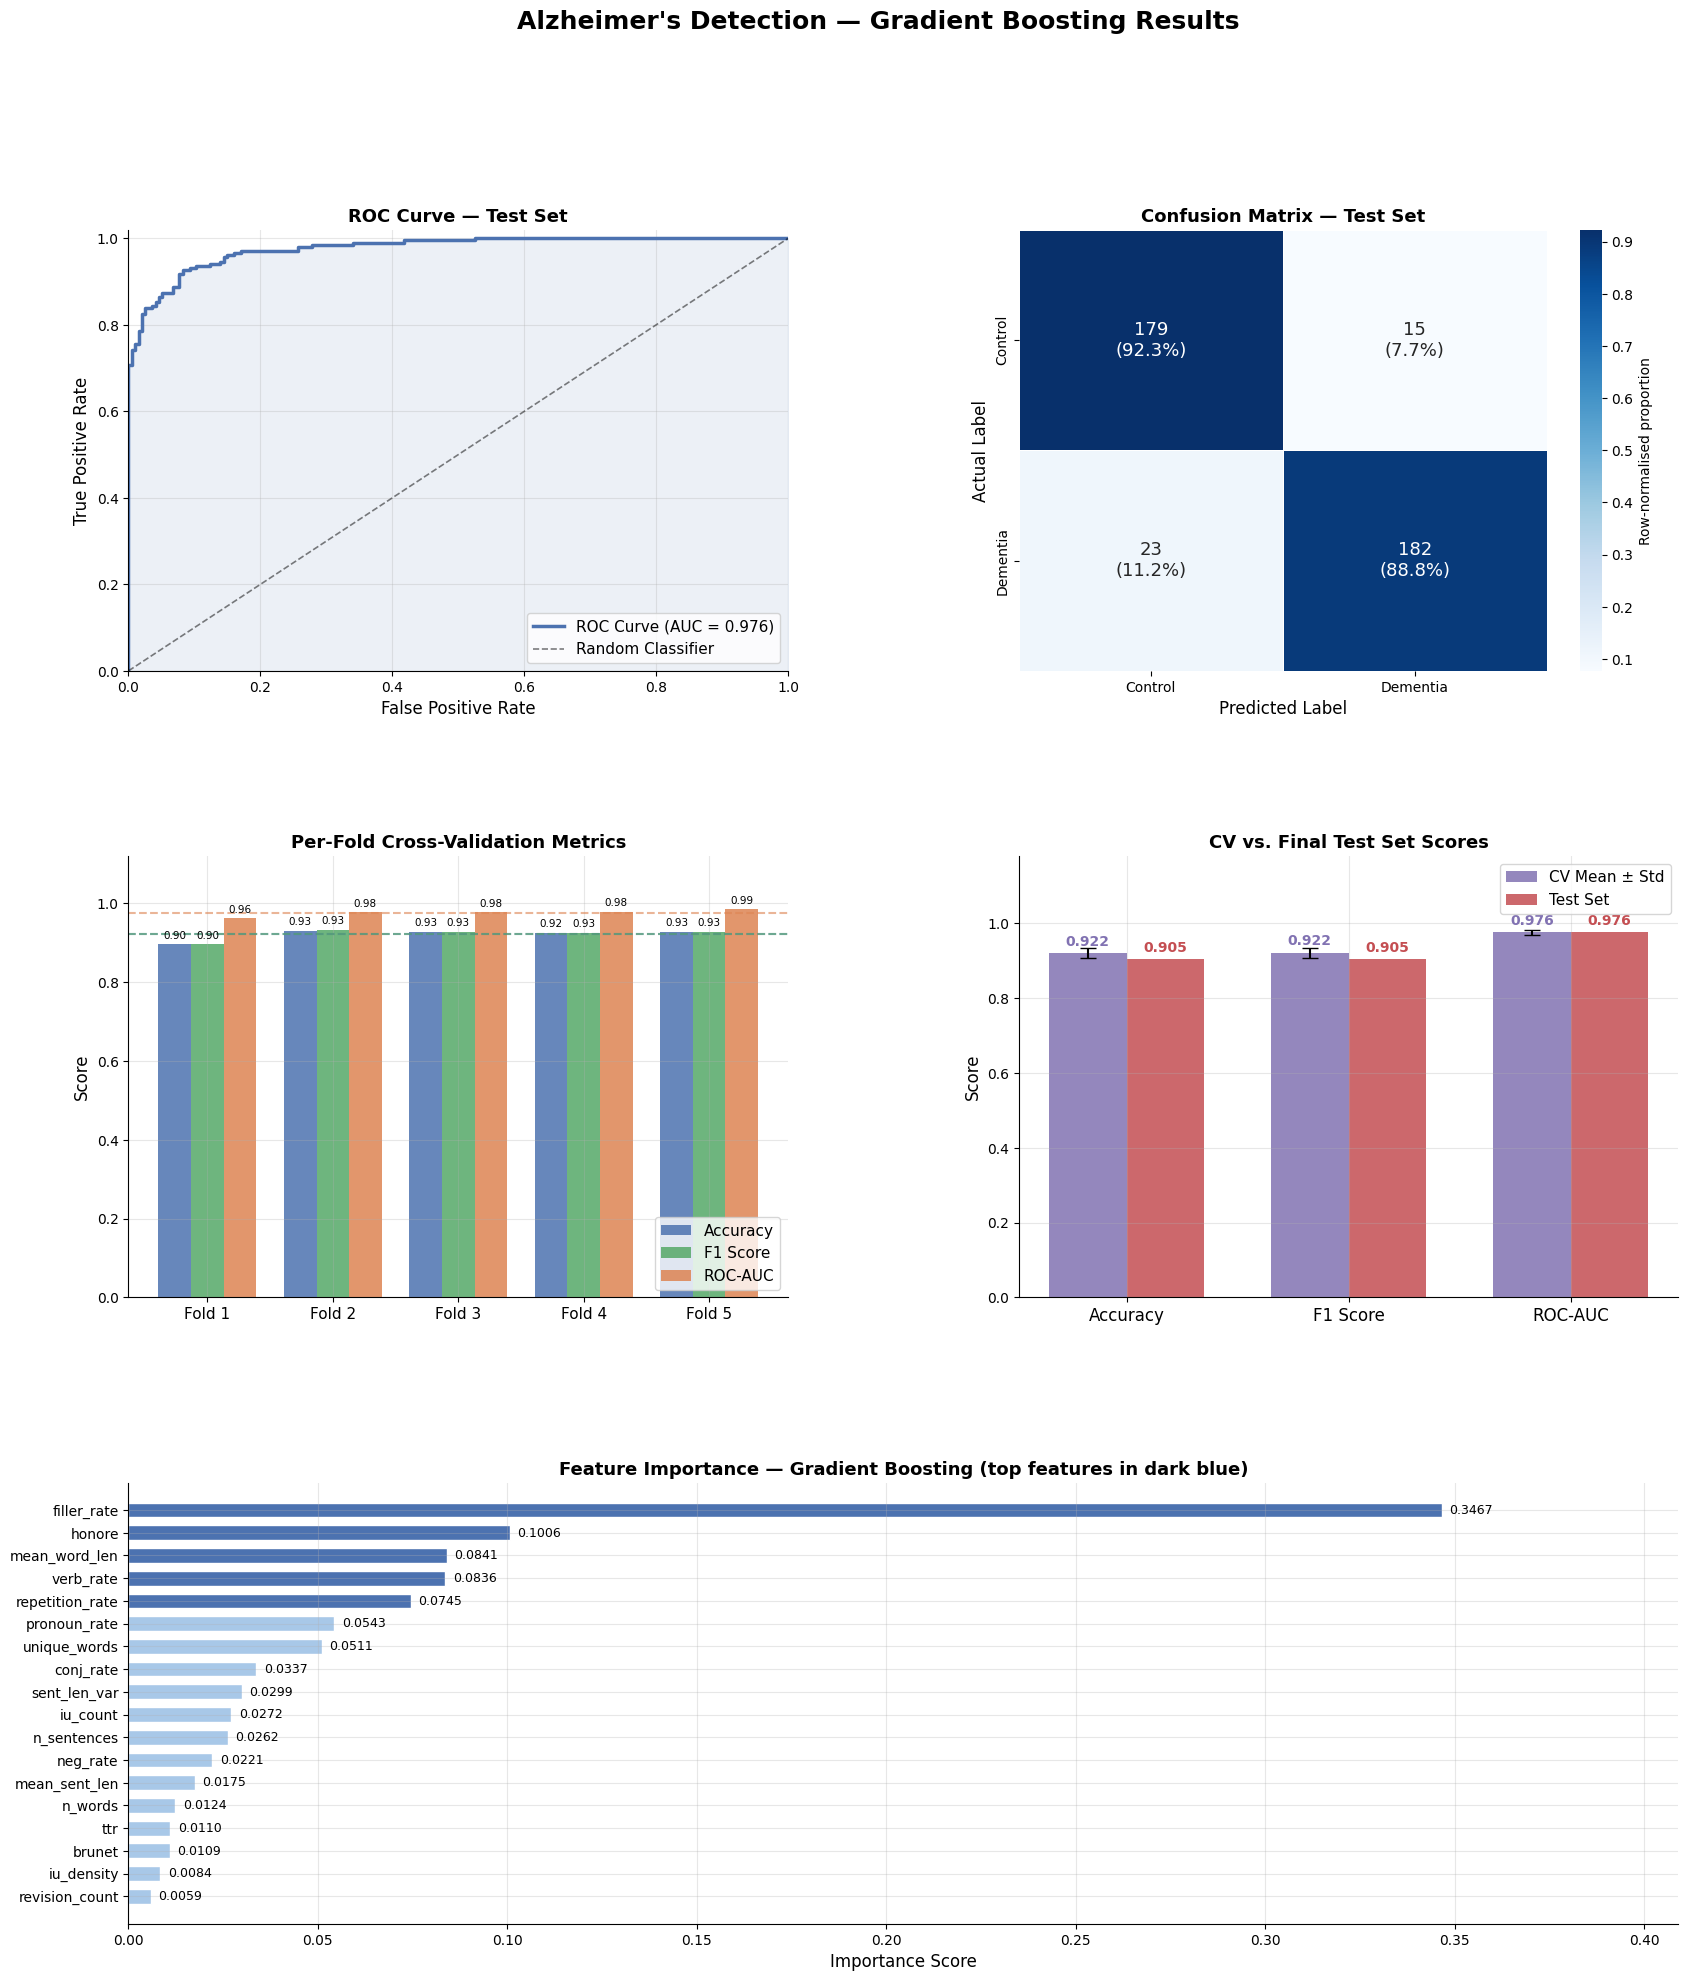


✅ All plots saved to results_plots.png


In [11]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import roc_curve, auc as sklearn_auc

# ── Style ──────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'figure.facecolor': 'white',
})
BLUE   = '#4C72B0'
ORANGE = '#DD8452'
GREEN  = '#55A868'
RED    = '#C44E52'
PURPLE = '#8172B2'

fig = plt.figure(figsize=(20, 22))
fig.suptitle('Alzheimer\'s Detection — Gradient Boosting Results',
             fontsize=18, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.42, wspace=0.35)

# ══════════════════════════════════════════════════════════════════
# PLOT 1 — ROC Curve
# ══════════════════════════════════════════════════════════════════
ax1 = fig.add_subplot(gs[0, 0])

fpr, tpr, _ = roc_curve(y_test, y_test_prob)
roc_auc_val = sklearn_auc(fpr, tpr)

ax1.plot(fpr, tpr, color=BLUE, lw=2.5,
         label=f'ROC Curve (AUC = {roc_auc_val:.3f})')
ax1.plot([0, 1], [0, 1], 'k--', lw=1.2, alpha=0.5, label='Random Classifier')
ax1.fill_between(fpr, tpr, alpha=0.10, color=BLUE)
ax1.set_xlim([0, 1])
ax1.set_ylim([0, 1.02])
ax1.set_xlabel('False Positive Rate', fontsize=12)
ax1.set_ylabel('True Positive Rate', fontsize=12)
ax1.set_title('ROC Curve — Test Set', fontsize=13, fontweight='bold')
ax1.legend(loc='lower right', fontsize=11)

# ══════════════════════════════════════════════════════════════════
# PLOT 2 — Confusion Matrix
# ══════════════════════════════════════════════════════════════════
ax2 = fig.add_subplot(gs[0, 1])

cm = confusion_matrix(y_test, y_test_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # row-normalised

annot = np.array([[f'{v}\n({p:.1%})' for v, p in zip(row_v, row_p)]
                   for row_v, row_p in zip(cm, cm_norm)])

sns.heatmap(
    cm_norm, annot=annot, fmt='', cmap='Blues',
    xticklabels=['Control', 'Dementia'],
    yticklabels=['Control', 'Dementia'],
    linewidths=0.5, linecolor='white',
    ax=ax2, cbar_kws={'label': 'Row-normalised proportion'},
    annot_kws={'size': 13}
)
ax2.set_xlabel('Predicted Label', fontsize=12)
ax2.set_ylabel('Actual Label', fontsize=12)
ax2.set_title('Confusion Matrix — Test Set', fontsize=13, fontweight='bold')
ax2.grid(False)

# ══════════════════════════════════════════════════════════════════
# PLOT 3 — Per-fold CV metrics
# ══════════════════════════════════════════════════════════════════
ax3 = fig.add_subplot(gs[1, 0])

folds   = [f'Fold {i}' for i in range(1, 6)]
x       = np.arange(len(folds))
width   = 0.26

b1 = ax3.bar(x - width, fold_acc, width, label='Accuracy', color=BLUE,   alpha=0.85)
b2 = ax3.bar(x,          fold_f1,  width, label='F1 Score', color=GREEN,  alpha=0.85)
b3 = ax3.bar(x + width,  fold_auc, width, label='ROC-AUC',  color=ORANGE, alpha=0.85)

# Mean lines
ax3.axhline(np.mean(fold_acc), color=BLUE,   ls='--', lw=1.5, alpha=0.6)
ax3.axhline(np.mean(fold_f1),  color=GREEN,  ls='--', lw=1.5, alpha=0.6)
ax3.axhline(np.mean(fold_auc), color=ORANGE, ls='--', lw=1.5, alpha=0.6)

ax3.set_xticks(x)
ax3.set_xticklabels(folds, fontsize=11)
ax3.set_ylim([0, 1.12])
ax3.set_ylabel('Score', fontsize=12)
ax3.set_title('Per-Fold Cross-Validation Metrics', fontsize=13, fontweight='bold')
ax3.legend(fontsize=11, loc='lower right')

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width() / 2, h + 0.01,
                 f'{h:.2f}', ha='center', va='bottom', fontsize=7.5)

# ══════════════════════════════════════════════════════════════════
# PLOT 4 — CV vs Test summary (mean ± std bar chart)
# ══════════════════════════════════════════════════════════════════
ax4 = fig.add_subplot(gs[1, 1])

metrics      = ['Accuracy', 'F1 Score', 'ROC-AUC']
cv_means     = [np.mean(fold_acc), np.mean(fold_f1), np.mean(fold_auc)]
cv_stds      = [np.std(fold_acc),  np.std(fold_f1),  np.std(fold_auc)]
test_scores  = [test_acc, test_f1, test_auc]

x2    = np.arange(len(metrics))
w2    = 0.35

ax4.bar(x2 - w2/2, cv_means, w2, yerr=cv_stds, capsize=6,
        label='CV Mean ± Std', color=PURPLE, alpha=0.85)
ax4.bar(x2 + w2/2, test_scores, w2,
        label='Test Set',      color=RED,    alpha=0.85)

for i, (cv_v, ts_v) in enumerate(zip(cv_means, test_scores)):
    ax4.text(i - w2/2, cv_v + 0.02, f'{cv_v:.3f}', ha='center', fontsize=10, color=PURPLE, fontweight='bold')
    ax4.text(i + w2/2, ts_v + 0.02, f'{ts_v:.3f}', ha='center', fontsize=10, color=RED,    fontweight='bold')

ax4.set_xticks(x2)
ax4.set_xticklabels(metrics, fontsize=12)
ax4.set_ylim([0, 1.18])
ax4.set_ylabel('Score', fontsize=12)
ax4.set_title('CV vs. Final Test Set Scores', fontsize=13, fontweight='bold')
ax4.legend(fontsize=11)

# ══════════════════════════════════════════════════════════════════
# PLOT 5 — Feature Importance (horizontal bar)
# ══════════════════════════════════════════════════════════════════
ax5 = fig.add_subplot(gs[2, :])

feat_names_sorted = [p[0] for p in imp_pairs]
feat_imps_sorted  = [p[1] for p in imp_pairs]

colors = [BLUE if i < 5 else '#A8C8E8' for i in range(len(feat_names_sorted))]
bars = ax5.barh(feat_names_sorted[::-1], feat_imps_sorted[::-1],
                color=colors[::-1], edgecolor='white', height=0.65)

for bar, val in zip(bars, feat_imps_sorted[::-1]):
    ax5.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
             f'{val:.4f}', va='center', fontsize=9)

ax5.set_xlabel('Importance Score', fontsize=12)
ax5.set_title('Feature Importance — Gradient Boosting (top features in dark blue)',
              fontsize=13, fontweight='bold')
ax5.set_xlim([0, max(feat_imps_sorted) * 1.18])

plt.savefig('results_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ All plots saved to results_plots.png")

## 11. Save Model & Summary

In [12]:
# Save trained model
joblib.dump(final_model, 'alzheimers_model.pkl')

# Save summary JSON
summary = {
    'model': 'Gradient Boosting (GradientBoostingClassifier)',
    'dataset_info': {
        'original_samples': int(len(df)),
        'dementia': int(df['label'].sum()),
        'control': int((df['label']==0).sum()),
        'train_size': int(len(y_train)),
        'test_size': int(len(y_test)),
        'n_features': len(FEAT_NAMES),
    },
    'cv_results': {
        'accuracy_mean': round(float(np.mean(fold_acc)), 4),
        'accuracy_std':  round(float(np.std(fold_acc)), 4),
        'f1_mean':       round(float(np.mean(fold_f1)), 4),
        'f1_std':        round(float(np.std(fold_f1)), 4),
        'auc_mean':      round(float(np.mean(fold_auc)), 4),
        'auc_std':       round(float(np.std(fold_auc)), 4),
    },
    'test_set_results': {
        'accuracy': round(float(test_acc), 4),
        'f1':       round(float(test_f1), 4),
        'auc':      round(float(test_auc), 4),
    },
    'feature_importance': {
        fname: round(float(imp), 4) for fname, imp in imp_pairs
    }
}

with open('pipeline_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("FILES SAVED:")
print("  alzheimers_model.pkl")
print("  pipeline_summary.json")
print("\n✅ Pipeline complete.")

FILES SAVED:
  alzheimers_model.pkl
  pipeline_summary.json

✅ Pipeline complete.
